# Test simulation for Valentine paper recreation
## Imports

In [7]:
import cmath
import math

import matplotlib.pyplot as plt
import numpy as np

import meep as mp
from meep import materials


## Transmittance Baseline
### Cell dimensions

In [8]:
resolution = 50  # pixels/μm

dpml = 1.0  # PML thickness
dsub = 6.0  # substrate thickness
dtop = 6.0 # encapsulant total thickness
ppx = 0.60  # pillar period in x
ppy = 0.600 # pillar period in y
ph = 0.440  # pillar height
pr = 0.140 # pillar radius



sz = dpml + dsub + ph + dtop + dpml
sy = ppy
sx = ppx

cell_size = mp.Vector3(sx, sy, sz)
pml_layers = [mp.PML(thickness=dpml, direction=mp.Z)]

### Source setup

In [9]:
wvl_min = 1  # min wavelength
wvl_max = 1.4  # max wavelength

# wvl = 1.1

fmin = 1 / wvl_max  # min frequency
fmax = 1 / wvl_min  # max frequency
fcen = 0.5 * (fmin + fmax)  # center frequency

# fcen = 1 / wvl

df = fmax - fmin  # frequency width

# df = 0.05 * fcen

src_pt = mp.Vector3(0, 0, 0.5 * sz - dpml - 0.5 * dtop)
sources = [
    mp.Source(
        mp.GaussianSource(fcen, fwidth=df),
        component=mp.Ex,
        center=src_pt,
        size=mp.Vector3(sx, sy, 0),
    )
]

### Simulation setup

In [10]:
k_point = mp.Vector3()

symmetries = [mp.Mirror(mp.X), mp.Mirror(mp.Y), mp.Rotate4(mp.Z)]

sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    k_point=k_point,
    sources=sources,
    symmetries=symmetries,
)

nfreq = 51
mon_pt = mp.Vector3(0, 0, -0.5 * sz + dpml + 0.5 * dsub)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(sx, sy, 0))
)

### Generate Transmittance baseline

In [11]:
sim.run(until_after_sources = 200)

trans_b = mp.get_fluxes(flux_mon)

-----------
Initializing structure...
Halving computational cell along direction x
Halving computational cell along direction y
time for choose_chunkdivision = 0.00104904 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.6 x 14.44 with resolution 50
time for set_epsilon = 0.100819 s
-----------
WARNING vol mismatch:, original_vol 578, looped vol_sum 2516 
WARNING vol mismatch:, original_vol 578, looped vol_sum 2516 
WARNING vol mismatch:, original_vol 578, looped vol_sum 2516 
WARNING vol mismatch:, original_vol 578, looped vol_sum 2516 


FloatProgress(value=0.0, description='0% done ', max=235.0)

Meep progress: 44.74/235.0 = 19.0% done in 4.0s, 17.0s to go
on time step 4476 (time=44.76), 0.000893784 s/step
Meep progress: 94.2/235.0 = 40.1% done in 8.0s, 12.0s to go
on time step 9422 (time=94.22), 0.000808745 s/step
Meep progress: 143.55/235.0 = 61.1% done in 12.0s, 7.6s to go
on time step 14358 (time=143.58), 0.000810539 s/step
Meep progress: 192.88/235.0 = 82.1% done in 16.0s, 3.5s to go
on time step 19291 (time=192.91), 0.000810879 s/step
run 0 finished at t = 235.0 (23500 timesteps)


## Test Setup 

### Cell setup

In [12]:
glass = materials.fused_quartz
pmma = materials.PMMA
silicon = materials.aSi

geometry = [
    mp.Block(
        material=glass,
        size=mp.Vector3(mp.inf, mp.inf, dpml + dsub),
        center=mp.Vector3(0, 0, -0.5 * sz + dpml + 0.5 * dsub),
    ),
    mp.Block(
        material=glass,
        size=mp.Vector3(mp.inf, mp.inf, dpml + dtop + ph),
        center=mp.Vector3(0, 0, 0.5 * sz - 0.5 * (dpml + dtop + ph)),
    ),
    mp.Cylinder(
        material = silicon,
        radius = pr, 
        height = ph, 
        axis = mp.Vector3(0, 0, 1),
        center = mp.Vector3(0, 0, 0.5 * ph)
    )
]


### Simulation setup

In [13]:
sim = mp.Simulation(
    resolution=resolution,
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    k_point=k_point,
    sources=sources,
    symmetries=symmetries,
)

nfreq = 51
mon_pt = mp.Vector3(0, 0, -0.5 * sz + dpml + 0.5 * dsub)
flux_mon = sim.add_flux(
    fcen, df, nfreq, mp.FluxRegion(center=mon_pt, size=mp.Vector3(sx, sy, 0))
)


## running the code

In [15]:
sim.run(until_after_sources=200)

-----------
Initializing structure...
Halving computational cell along direction x
Halving computational cell along direction y
time for choose_chunkdivision = 0.000741005 s
Working in 3D dimensions.
Computational cell is 0.6 x 0.6 x 14.44 with resolution 50
     block, center = (0,0,-3.22)
          size (1e+20,1e+20,7)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (0,0,3.5)
          size (1e+20,1e+20,7.44)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     cylinder, center = (0,0,0.22)
          radius 0.14, height 0.44, axis (0, 0, 1)
          dielectric constant epsilon diagonal = (3.109,3.109,3.109)
time for set_epsilon = 0.267384 s
lorentzian susceptibility: frequency=3.16976, gamma=1.54858
lorentzian susceptibility: frequency=0.101049, gamma=0
lorentzian susceptibility: frequency=8.60279, gamma=0
lorentzian susceptibility: frequency=14.619, gamma=0
-----

/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1664: RuntimeWarning: Note: your sources include frequencies outside the range of validity of the material models. This is fine as long as you eventually only look at outputs (fluxes, resonant modes, etc.) at valid frequencies.
  warnings.warn(warn_src, RuntimeWarning)
/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 0.7142857142857144 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(
/Applications/anaconda3/envs/ImgDiff/lib/python3.13/site-packages/meep/simulation.py:1668: RuntimeWarning: DFT frequency 1.0 is out of material's range of 1.2048192771084338-4.761904761904762
  warnings.warn(


FloatProgress(value=0.0, description='0% done ', max=235.0)

Meep progress: 10.4/235.0 = 4.4% done in 4.0s, 86.4s to go
on time step 1041 (time=10.41), 0.00384531 s/step
Meep progress: 23.06/235.0 = 9.8% done in 8.0s, 73.6s to go
on time step 2307 (time=23.07), 0.00316151 s/step
Meep progress: 35.95/235.0 = 15.3% done in 12.0s, 66.5s to go
on time step 3596 (time=35.96), 0.00310414 s/step
Meep progress: 48.88/235.0 = 20.8% done in 16.0s, 60.9s to go
on time step 4889 (time=48.89), 0.00309383 s/step
Meep progress: 61.85/235.0 = 26.3% done in 20.0s, 56.0s to go
on time step 6186 (time=61.86), 0.00308426 s/step
Meep progress: 74.74/235.0 = 31.8% done in 24.0s, 51.5s to go
on time step 7475 (time=74.75), 0.00310337 s/step
Meep progress: 87.91/235.0 = 37.4% done in 28.0s, 46.9s to go
on time step 8792 (time=87.92), 0.0030379 s/step
Meep progress: 101.07000000000001/235.0 = 43.0% done in 32.0s, 42.4s to go
on time step 10108 (time=101.08), 0.0030402 s/step
Meep progress: 114.13/235.0 = 48.6% done in 36.0s, 38.1s to go
on time step 11414 (time=114.14),

In [16]:
tran_new = mp.get_fluxes(flux_mon)

flux_freqs = mp.get_flux_freqs(flux_mon)

wl = []
Ts = []
for i in range(nfreq):
    wl = np.append(wl, 1/flux_freqs[i])
    Ts = np.append(Ts,tran_new[i]/trans_b[i])



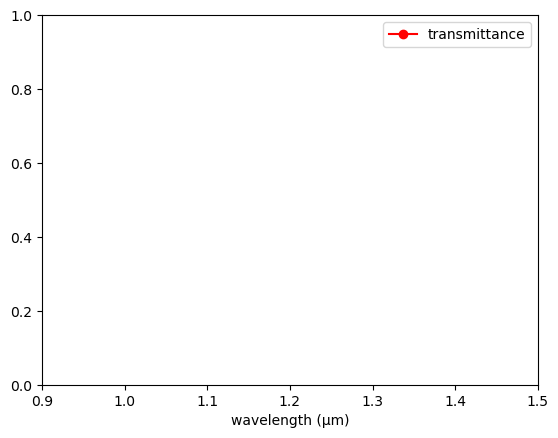

In [17]:
plt.figure()
plt.plot(wl,Ts,'ro-',label='transmittance')
plt.axis([0.9, 1.5, 0, 1])
plt.xlabel("wavelength (μm)")
plt.legend(loc="upper right")
plt.show()

In [19]:
print(tran_new[1]/trans_b[1])

nan
